# Rust (1987): Optimal Engine Replacement

David Evans  
2026-02-23

# Introduction

## From McCall to Rust

### Recap: The McCall Search Model

-   An unemployed worker receives random wage offers each period
-   Two choices: **accept** (become employed) or **reject** (keep
    searching)
-   Solved via **dynamic programming** and the Bellman equation

. . .

-   The key insight: there exists a **reservation wage** — accept
    anything above it, reject anything below

### From Optimal Search to Optimal Replacement

-   McCall (1970): when should a worker **stop searching** and accept a
    job?
-   Rust (1987): when should a bus superintendent **stop maintaining**
    and replace an engine?

. . .

|  | McCall | Rust |
|------------------------|------------------------|------------------------|
| **Agent** | Unemployed worker | Bus superintendent |
| **State** | Wage offer | Accumulated mileage |
| **Choice** | Accept / Reject | Replace / Keep |
| **Tradeoff** | Good wage now vs. better offer later | Replacement cost vs. rising maintenance |

. . .

-   Both are **dynamic discrete choice** problems solved by dynamic
    programming

### Harold Zurcher

-   Bus maintenance superintendent at the **Madison Metropolitan Bus
    Company**
-   Manages a fleet of GMC buses
-   Each period, decides: **replace** the engine or **keep** running it?

. . .

> **The Key Tradeoff**
>
> Replacing is expensive but resets the engine to new condition. Keeping
> is cheap today but maintenance costs **rise with mileage**.

### Why This Paper Matters

-   **Rust (1987, *Econometrica*)** — foundational paper in **structural
    econometrics**
-   Shows how to **estimate** a dynamic programming model from observed
    data
-   Introduced the **Nested Fixed Point (NFXP)** algorithm

. . .

-   Framework used across economics:
    -   Firm entry/exit decisions
    -   Investment under uncertainty
    -   Health decisions, migration, education

## Roadmap

### What We’ll Cover

1.  **The Environment** — states, actions, payoffs, and mileage
    transitions
2.  **Choices with Extreme Value Shocks** — how unobserved shocks lead
    to logit probabilities
3.  **Solving the DP** — Bellman equation and value function iteration
4.  **Estimation** — recovering structural parameters from data using
    NFXP

# The Environment

## The Agent’s Problem

### The Setup

-   Zurcher manages a fleet of buses, each characterized by
    **accumulated mileage** $x_t$
-   Mileage is **discretized** into $S$ bins (e.g., each bin = 5,000
    miles)

. . .

-   Each period, Zurcher observes $x_t$ and chooses:
    -   $d_t = 0$: **Keep** the current engine
    -   $d_t = 1$: **Replace** the engine (mileage resets to 0)

### Per-Period Payoffs

-   **Keep** ($d_t = 0$): pay maintenance cost $c(x_t, \theta_1)$

$$
u(x_t, 0) = -c(x_t, \theta_1)
$$

. . .

-   **Replace** ($d_t = 1$): pay replacement cost $RC$, engine resets to
    new

$$
u(x_t, 1) = -RC
$$

. . .

-   These are the payoffs the **econometrician can compute** from data
    on mileage and costs

### Unobserved Components

-   But the agent also considers factors we **can’t see**: weather
    conditions, driver complaints, parts availability, gut feeling…

. . .

-   We model these as **random shocks** $\varepsilon_t(d)$ added to each
    option:

$$
\tilde{u}(x_t, d) = u(x_t, d) + \varepsilon_t(d)
$$

. . .

-   Key assumptions:
    -   $\varepsilon_t(0)$ and $\varepsilon_t(1)$ are **iid** across
        options and time
    -   Independent of the observed state $x_t$ (**Conditional
        Independence**)

. . .

-   What distribution should we assume for $\varepsilon$? This is a
    **modeling choice** — and it turns out to matter a lot. We’ll tackle
    this next.

### The Cost Function

-   We use a **linear specification**:
    $c(x, \theta_1) = \theta_1 \cdot x$

. . .

-   Higher mileage $\rightarrow$ higher maintenance costs
-   At $x = 0$ (new engine): maintenance cost is zero

. . .

-   Two structural parameters to estimate:
    -   $\theta_1$: how fast maintenance costs rise with mileage
    -   $RC$: the one-time cost of engine replacement

### Mileage Transitions

-   Each period, mileage increases by a **random increment**
    $\Delta x \in \{0, 1, 2\}$ bins

$$
\Pr(\Delta x = k) = \theta_{3,k+1} \quad \text{for } k = 0, 1, 2
$$

. . .

-   If **keep** ($d_t = 0$): $x_{t+1} = x_t + \Delta x$
-   If **replace** ($d_t = 1$): $x_{t+1} = 0 + \Delta x$ (mileage
    resets, then accumulates)

. . .

-   At the boundary ($x = S$), mileage is capped

## Setup in Julia

### Loading Packages

In [1]:
using Plots
using LinearAlgebra
using Statistics
using Distributions
using Random

### The `RustModel` Struct

-   We bundle all model parameters into a struct (as we did with
    `McCallModel`):

In [1]:
@kwdef struct RustModel
    β::Float64 = 0.95                                # discount factor
    S::Int = 50                                       # number of mileage bins
    RC::Float64 = 20.0                                # replacement cost
    θ₁::Float64 = 0.04                               # maintenance cost parameter
    θ₃::Vector{Float64} = [0.36, 0.48, 0.16]         # transition probabilities
    x̄::Vector{Float64} = Float64.(0:S-1)             # mileage states
    c::Vector{Float64} = θ₁ * x̄                      # cost at each mileage level
end

RustModel

### Creating an Instance

In [1]:
m = RustModel()                                      # all defaults
(; x̄, c, S, β, RC, θ₃) = m                          # destructure for easy access

RustModel(0.95, 50, 20.0, 0.04, [0.36, 0.48, 0.16], [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0], [0.0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36  …  1.6, 1.6400000000000001, 1.68, 1.72, 1.76, 1.8, 1.84, 1.8800000000000001, 1.92, 1.96])

### Plotting the Cost Function


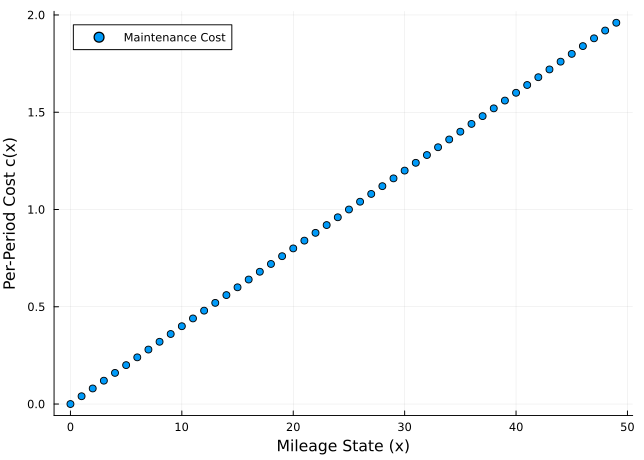

In [1]:
scatter(x̄, c, label="Maintenance Cost", legend=:topleft)
xlabel!("Mileage State (x)")
ylabel!("Per-Period Cost c(x)")

-   Maintenance costs rise linearly — the engine becomes more expensive
    to maintain as mileage accumulates

### Building Transition Matrices

-   We need two transition matrices:
    -   $F_0$: transitions when the agent **keeps** the engine
    -   $F_1$: transitions when the agent **replaces** the engine

In [1]:
function buildTransition(θ₃, S)
    K = length(θ₃)                          # number of possible increments
    #Pre-allocate the transition matrices

    for i in 1:S                           # loop over current states
        for k in 1:K                       # loop over possible increments
            #Fill in keep transition matrix
            #Fill in replace transition matrix
        end
    end
    #Return constructed transition matrices
end

### Building Transition Matrices

-   We need two transition matrices:
    -   $F_0$: transitions when the agent **keeps** the engine
    -   $F_1$: transitions when the agent **replaces** the engine

In [1]:
function buildTransition(θ₃, S)
    K = length(θ₃)                          # number of possible increments
    
    F0 = zeros(S, S)                       # keep transition matrix: mileage goes up
    F1 = zeros(S, S)                       # replace transition matrix: mileage resets

    for i in 1:S                           # loop over current states
        for k in 1:K                       # loop over possible increments
            j_keep = min(i + k - 1, S)     
            F0[i, j_keep] += θ₃[k]          # keep transition: state i → state i + (k-1)

            j_replace = min(k, S)           
            F1[i, j_replace] += θ₃[k]       # replace transition: any state → state (k)
        end
    end
    return F0, F1
end

buildTransition (generic function with 1 method)

### Computing the Transition Matrices

In [1]:
F0, F1 = buildTransition(θ₃, S)

([0.36 0.48 … 0.0 0.0; 0.0 0.36 … 0.0 0.0; … ; 0.0 0.0 … 0.36 0.64; 0.0 0.0 … 0.0 1.0], [0.36 0.48 … 0.0 0.0; 0.36 0.48 … 0.0 0.0; … ; 0.36 0.48 … 0.0 0.0; 0.36 0.48 … 0.0 0.0])

-   $F_0$ row $i$: distribution of next state given current state $i$
    and **keep**
-   $F_1$ row $i$: distribution of next state given **replace** (same
    for all $i$)

. . .

In [1]:
F0[1, 1:5]    # from state 1 (new engine): can go to states 1, 2, or 3

5-element Vector{Float64}:
 0.36
 0.48
 0.16
 0.0
 0.0

In [1]:
F1[25, 1:5]   # after replacement from state 25: same as starting fresh

5-element Vector{Float64}:
 0.36
 0.48
 0.16
 0.0
 0.0

### Transition Matrix Structure - Keep Engine


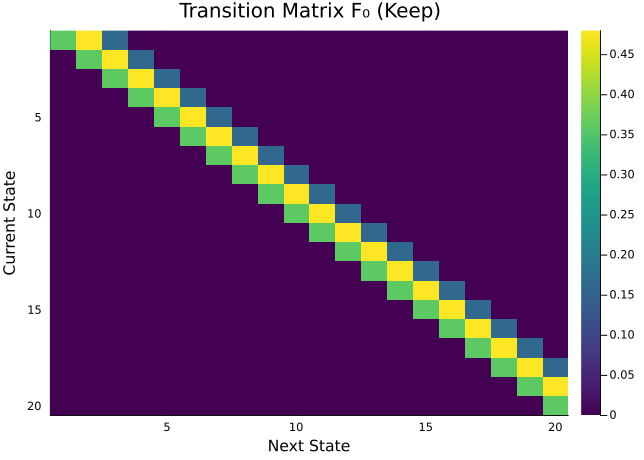

In [1]:
heatmap(F0[1:20, 1:20], xlabel="Next State", ylabel="Current State",
        title="Transition Matrix F₀ (Keep)", color=:viridis, yflip=true)

-   Band structure: mileage can only increase by 0, 1, or 2 bins per
    period

### Transition Matrix Structure - Replace Engine


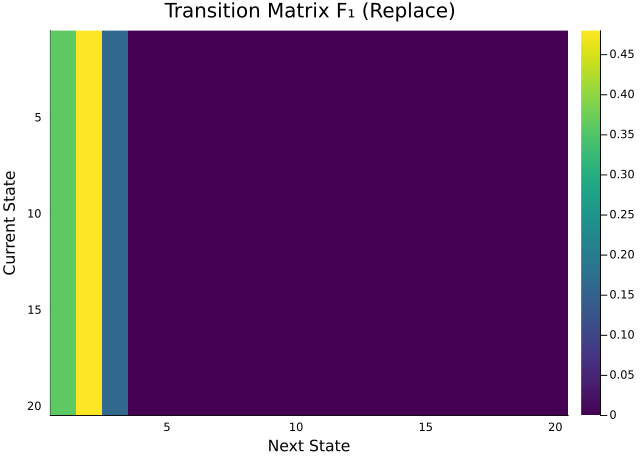

In [1]:
heatmap(F1[1:20, 1:20], xlabel="Next State", ylabel="Current State",
        title="Transition Matrix F₁ (Replace)", color=:viridis, yflip=true)

-   All rows are the same: replacing resets the engine to mileage to 0

# Choices with Extreme Value Shocks

## The Static Choice Problem

### Setting Up the Problem

-   Before solving the full DP, let’s understand a **simpler** problem
-   An agent chooses between two options with payoffs:

$$
\text{Option 0: } v_0 + \varepsilon_0 \qquad \text{Option 1: } v_1 + \varepsilon_1
$$

. . .

-   $v_0, v_1$: the **observable** (deterministic) payoff components
-   $\varepsilon_0, \varepsilon_1$: **unobservable** (random) shocks
    known to the agent but not to us

. . .

-   The agent picks the option with the **highest total payoff**:

$$
d^* = \arg\max_d \left\{ v_d + \varepsilon_d \right\}
$$

### Why Model Unobserved Shocks?

-   Without shocks: the model predicts **deterministic** choices —
    everyone at the same mileage makes the **same** decision

. . .

-   But in the data, we see buses at **similar mileage** making
    **different** choices

. . .

-   With shocks: the model generates **probabilistic** choices —
    consistent with the data

. . .

> **A Modeling Choice**
>
> We need to choose a distribution for $\varepsilon$. This is a
> **modeling assumption** that affects both the math and the economics.
> Rust chose the Type I Extreme Value distribution.

### The Expected Maximum

-   The **value** of facing this choice (before seeing the shocks) is:

$$
\mathbb{E}\left[\max_d \left\{ v_d + \varepsilon_d \right\}\right]
$$

. . .

-   This is the expected payoff from the **best option** — it matters
    for the Bellman equation because today’s value depends on what you
    expect to do **optimally tomorrow**

. . .

-   Can we compute this in closed form? It depends on the distribution
    of $\varepsilon$

## The Type I Extreme Value Distribution

### The Distribution

-   The **Type I Extreme Value** (Gumbel) distribution has CDF:

$$
F(\varepsilon) = e^{-e^{-\varepsilon}}
$$

. . .

-   Mean: $\gamma \approx 0.5772$ (Euler–Mascheroni constant)
-   Variance: $\pi^2 / 6 \approx 1.645$
-   Right-skewed: extreme positive shocks are possible but rare

### Generating Extreme Value Draws

-   If $U \sim \text{Uniform}(0,1)$, then
    $\varepsilon = -\log(-\log(U))$ has the Type I EV distribution

In [1]:
N = 100_000
ε_draws = -log.(-log.(rand(N)))
println("Sample mean: ", round(mean(ε_draws), digits=3), "  (theory: 0.577)")
println("Sample var:  ", round(var(ε_draws), digits=3), "  (theory: 1.645)")

Sample mean: 0.575  (theory: 0.577)
Sample var:  1.656  (theory: 1.645)

### Plotting the Distribution


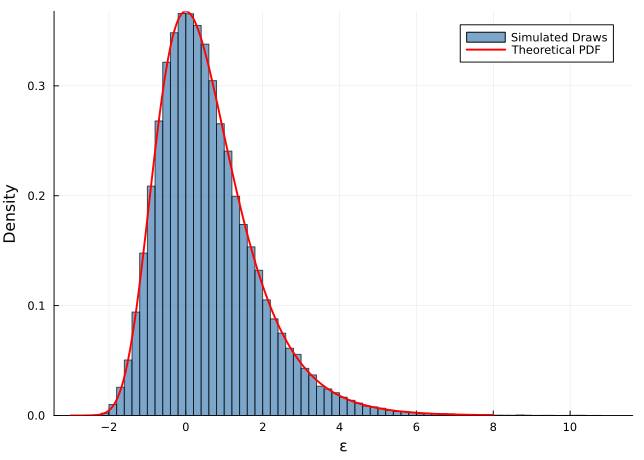

In [1]:
histogram(ε_draws, bins=100, normalize=true, label="Simulated Draws",
          alpha=0.7, color=:steelblue)
ε_grid = LinRange(-3, 8, 200)
pdf_ev = exp.(-ε_grid .- exp.(-ε_grid))             # f(ε) = exp(-ε - exp(-ε))
plot!(ε_grid, pdf_ev, linewidth=2, color=:red, label="Theoretical PDF")
xlabel!("ε")
ylabel!("Density")

-   Right-skewed: the agent occasionally gets a **very favorable**
    unobserved shock

## Two Key Results

### Result 1: The Expected Maximum

> **Theorem (Log-Sum-Exp)**
>
> If $\varepsilon_0, \varepsilon_1$ are iid Type I Extreme Value, then:
>
> $$
> \mathbb{E}\left[\max\{v_0 + \varepsilon_0,\; v_1 + \varepsilon_1\}\right] = \log\left(e^{v_0} + e^{v_1}\right) + \gamma
> $$
>
> where $\gamma \approx 0.5772$ is Euler’s constant.

. . .

-   This extends to $J$ options:
    $\mathbb{E}\left[\max_j\{v_j + \varepsilon_j\}\right] = \log\left(\sum_j e^{v_j}\right) + \gamma$

### Monte Carlo: Verifying the Expected Maximum

-   Let’s check with simulation: set $v_0 = 2$ and $v_1 = 3$

In [1]:
v0_val = 2.0
v1_val = 3.0

ε0 = -log.(-log.(rand(N)))                          # N extreme value draws
ε1 = -log.(-log.(rand(N)))                          # N independent draws

max_payoffs = max.(v0_val .+ ε0, v1_val .+ ε1)      # simulated max for each draw
const γ_euler = Base.MathConstants.eulergamma       # Euler's constant ≈ 0.5772

theoretical = log(exp(v0_val) + exp(v1_val)) + γ_euler
println("Simulated E[max]:   ", round(mean(max_payoffs), digits=4))
println("Theoretical:        ", round(theoretical, digits=4))

Simulated E[max]:   3.8965
Theoretical:        3.8905

### Function: Verifying the Expected Maximum

In [1]:
function verifyExpectedMaximum(v0_val, v1_val, N)
    #N extreme value draws for ε0 and ε1
    #simulate max payoff for each draw
    #compute theoretical expected maximum
    #return simulated and theoretical expected maximum
end

verifyExpectedMaximum (generic function with 1 method)

### Function: Verifying the Expected Maximum

In [1]:
function verifyExpectedMaximum(v0_val, v1_val, N)
    #N extreme value draws for ε0 and ε1
    ε0 = -log.(-log.(rand(N)))
    ε1 = -log.(-log.(rand(N)))
    #simulate max payoff for each draw
    max_payoffs = max.(v0_val .+ ε0, v1_val .+ ε1)
    #compute theoretical expected maximum
    theoretical = log(exp(v0_val) + exp(v1_val)) + γ_euler
    #return simulated and theoretical expected maximum
    return mean(max_payoffs), theoretical
end

verifyExpectedMaximum (generic function with 1 method)

### Monte Carlo: Varying the Gap

-   How does $\mathbb{E}[\max]$ change as $v_1 - v_0$ varies?

In [1]:
#Preallocate arrays

#Loop through each value of Δv

#Plot the results

### Monte Carlo: Varying the Gap

-   How does $\mathbb{E}[\max]$ change as $v_1 - v_0$ varies?


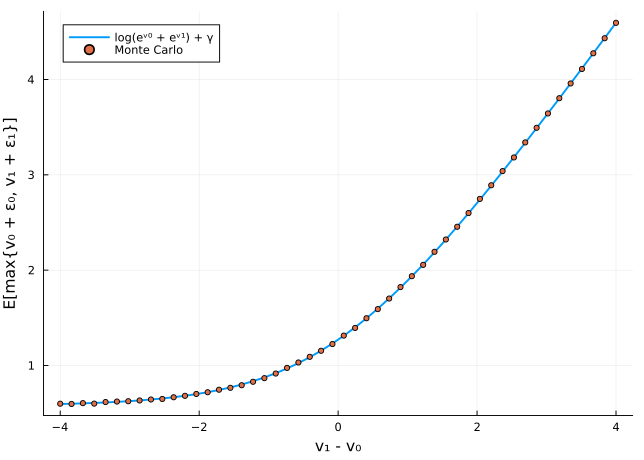

In [1]:
#Preallocate arrays
Δv_grid = LinRange(-4, 4, 50)
Emax_sim = zeros(length(Δv_grid))
Emax_theory = zeros(length(Δv_grid))

#Loop through each value of Δv
for (i, Δv) in enumerate(Δv_grid)
    Emax_sim[i], Emax_theory[i] = verifyExpectedMaximum(0.0, Δv, N)
end

#Plot the results
plot(Δv_grid, Emax_theory, linewidth=2, label="log(eᵛ⁰ + eᵛ¹) + γ", legend=:topleft)
scatter!(Δv_grid, Emax_sim, label="Monte Carlo", markersize=3)
xlabel!("v₁ - v₀")
ylabel!("E[max{v₀ + ε₀, v₁ + ε₁}]")

. . .

-   The formula matches perfectly — even when the options are close in
    value

### Result 2: Choice Probabilities

> **Theorem (Logit Formula)**
>
> If $\varepsilon_0, \varepsilon_1$ are iid Type I Extreme Value, then:
>
> $$
> P(d = 1) = \Pr(v_1 + \varepsilon_1 > v_0 + \varepsilon_0) = \frac{e^{v_1}}{e^{v_0} + e^{v_1}} = \frac{1}{1 + e^{v_0 - v_1}}
> $$

. . .

-   This is the **logit formula** — the same one from discrete choice
    econometrics!
-   The probability of choosing option 1 depends only on the
    **difference** $v_1 - v_0$

### Monte Carlo: Verifying Choice Probabilities

In [1]:
choices = (v1_val .+ ε1) .> (v0_val .+ ε0)          # 1 if option 1 chosen
simulated_prob = mean(choices)

theoretical_prob = exp(v1_val) / (exp(v0_val) + exp(v1_val))
println("Simulated P(d=1):   ", round(simulated_prob, digits=4))
println("Theoretical P(d=1): ", round(theoretical_prob, digits=4))

Simulated P(d=1):   0.729
Theoretical P(d=1): 0.7311

. . .

-   With $v_0 = 2, v_1 = 3$: option 1 has higher deterministic value, so
    $P(d=1) > 0.5$
-   But it’s not 1.0 — the shocks sometimes make option 0 the better
    choice

### Function: Verifying Choice Probabilities

In [1]:
function verifyChoiceProbabilities(v0_val, v1_val, N)
    #N extreme value draws for ε0 and ε1
    ε0 = -log.(-log.(rand(N)))
    ε1 = -log.(-log.(rand(N)))
    #simulate choices for each draw
    choices = (v1_val .+ ε1) .> (v0_val .+ ε0)
    #compute theoretical choice probability
    theoretical = exp(v1_val) / (exp(v0_val) + exp(v1_val))
    return mean(choices), theoretical
end

verifyChoiceProbabilities (generic function with 1 method)

### Monte Carlo: The Logit Curve


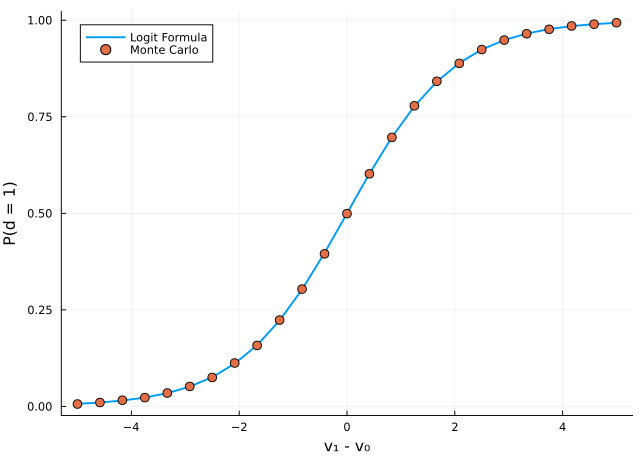

In [1]:
# Preallocate arrays
Δv_points = LinRange(-5, 5, 25)
P_mc = zeros(length(Δv_points))
P_theory = zeros(length(Δv_points))

#Loop through each value of Δv
for (i, Δv) in enumerate(Δv_points)
    P_mc[i], P_theory[i] = verifyChoiceProbabilities(0.0, Δv, N)
end

#Plot the results
plot(Δv_points, P_theory, linewidth=2, label="Logit Formula", legend=:topleft)
scatter!(Δv_points, P_mc, label="Monte Carlo", markersize=5)
xlabel!("v₁ - v₀")
ylabel!("P(d = 1)")

. . .

-   S-shaped curve: smooth transition from “never choose 1” to “always
    choose 1”

## What’s Next?

### From Static Choices to Dynamic Programming

-   We now have two powerful tools from the extreme value assumption:
    1.  **Log-sum-exp**:
        $\mathbb{E}[\max\{v_0 + \varepsilon_0, v_1 + \varepsilon_1\}] = \log(e^{v_0} + e^{v_1}) + \gamma$
    2.  **Logit**: $P(d=1) = e^{v_1} / (e^{v_0} + e^{v_1})$

. . .

-   These hold for **any** values $v_0, v_1$
-   Next: we define $v^{\text{keep}}$ and $v^{\text{replace}}$ for the
    Rust model — then apply these results to build the Bellman equation

# Solving the Dynamic Problem

## The Bellman Equation

### Zurcher’s Optimization Problem

-   Zurcher maximizes **expected discounted lifetime utility**:

$$
\max_{d_t} \; \mathbb{E} \left[ \sum_{t=0}^{\infty} \beta^t \left( u(x_t, d_t, \theta_1) + \varepsilon_t(d_t) \right) \right]
$$

. . .

-   Same structure as McCall, but the state evolves stochastically
    regardless of the action (mileage always goes up)

-   As always, the problem can be tackled with a let statement

    -   Let $V(x)$ be the value of having a bus in state $x$ before the
        shocks $\varepsilon$ are realized

### Choice-Specific Value Functions

-   Just like McCall, define the value of each option. The value of
    **keeping** at mileage $x$:

$$
v^{\text{keep}}(x) = -c(x, \theta_1) + \beta \sum_{x'} F_0(x, x') \cdot V(x')
$$

. . .

-   The value of **replacing** at mileage $x$:

$$
v^{\text{replace}}(x) = -RC + \beta \sum_{x'} F_1(x, x') \cdot V(x')
$$

. . .

-   Flow payoff today + discounted continuation — the same structure as
    McCall’s $V_{\text{accept}}$ and $V_{\text{reject}}$
-   These are the $v_0$ and $v_1$ from our extreme value analysis!

### Defining $V(x)$

-   With $v^{\text{keep}}(x)$ and $v^{\text{replace}}(x)$ defined, the
    agent at state $x$ faces exactly the choice we studied:

$$
\max\left\{ v^{\text{keep}}(x) + \varepsilon_0, \;\; v^{\text{replace}}(x) + \varepsilon_1 \right\}
$$

. . .

-   We define $V(x)$ as the value of having a bus in state $x$
    **before** the shocks are realized:

$$
\boxed{V(x) \equiv \mathbb{E}_\varepsilon\left[\max\left\{ v^{\text{keep}}(x) + \varepsilon_0, \;\; v^{\text{replace}}(x) + \varepsilon_1 \right\}\right]}
$$

. . .

-   Compare to McCall:
    $V_s = \max\{V_{\text{accept},s},\; V_{\text{reject},s}\}$. Here we
    take an **expected** max because of the unobserved shocks.

### The Bellman Equation

-   Applying **Result 1** (log-sum-exp):

$$
V(x) = \log\left(e^{v^{\text{keep}}(x)} + e^{v^{\text{replace}}(x)}\right) + \gamma
$$

. . .

-   The Euler constant $\gamma$ is just a level shift — dropping it
    doesn’t affect choices or convergence:

$$
\boxed{V(x) = \log\left(\exp(v^{\text{keep}}(x)) + \exp(v^{\text{replace}}(x))\right)}
$$

. . .

> **Fixed Point Problem**
>
> $V$ appears on **both sides**: on the left directly, and on the right
> inside $v^{\text{keep}}$ and $v^{\text{replace}}$. Just like in
> McCall, we solve by iterating until convergence.

### Choice Probabilities

-   Applying **Result 2** (logit), the probability of replacing at
    mileage $x$:

$$
P(d = 1 \mid x) = \frac{\exp(v^{\text{replace}}(x))}{\exp(v^{\text{keep}}(x)) + \exp(v^{\text{replace}}(x))} = \frac{1}{1 + \exp(v^{\text{keep}}(x) - v^{\text{replace}}(x))}
$$

. . .

> **Static Logit vs. Dynamic Logit**
>
> This is the same **logit formula** we verified with Monte Carlo. The
> difference: $v^{\text{keep}}$ and $v^{\text{replace}}$ incorporate the
> entire **future path** of costs and decisions — the agent is
> **forward-looking**, not myopic.

### In Matrix Notation

-   Using vectors and matrices, the Bellman equation becomes:

$$
v^{\text{keep}} = -c + \beta \, F_0 \, V
$$ $$
v^{\text{replace}} = -RC \cdot \mathbf{1} + \beta \, F_1 \, V
$$

. . .

-   Note: since $F_1$ has **identical rows**, $F_1 \cdot V$ is the same
    scalar for every $x$
-   The value of replacing does **not depend on current mileage** —
    you’re getting a fresh engine regardless

## Value Function Iteration

### The Bellman Operator: Pseudocode

In [0]:
function iterateBellman(m::RustModel, V, F0, F1)
    # Compute choice-specific values: v_keep and v_replace
    # Combine using log-sum-exp: V(x) = log(exp(v_keep) + exp(v_replace))
    # Return updated V
end

### The Bellman Operator: Choice-Specific Values

-   The two components of the Bellman equation:

In [0]:
function iterateBellman(m::RustModel, V, F0, F1)
    (; β, RC, c) = m
    v_keep = -c + β * (F0 * V)                      # flow cost + β × E[V | keep]
    v_replace = (-RC) .+ β * (F1 * V)               # replacement cost + β × E[V | replace]
    # ...
end

. . .

-   `F0 * V`: matrix-vector multiplication computes
    $\sum_{x'} F_0(x, x') V(x')$ for every $x$
-   `v_keep` falls with mileage (higher maintenance costs)
-   `v_replace` is nearly constant (resetting makes current mileage
    irrelevant)

### The Bellman Operator: Log-Sum-Exp

In [1]:
function iterateBellman(m::RustModel, V, F0, F1)
    (; β, RC, c) = m
    v_keep = -c + β * (F0 * V)                      # value of keeping
    v_replace = (-RC) .+ β * (F1 * V)               # value of replacing
    vmax = max.(v_keep, v_replace)                   # for numerical stability
    V_new = vmax + log.(exp.(v_keep - vmax)          # log-sum-exp trick:
                      + exp.(v_replace - vmax))      #   prevents overflow
    return V_new
end

iterateBellman (generic function with 1 method)

. . .

> **Log-Sum-Exp Trick**
>
> We compute $\log(e^a + e^b) = m + \log(e^{a-m} + e^{b-m})$ where
> $m = \max(a,b)$. This prevents numerical overflow when $a$ or $b$ are
> large.

### Iterating to Convergence

In [1]:
V = zeros(S)                                         # initial guess: all zeros
dist = 1.0                                           # initialize distance

niter = 0                                            # count iterations
while dist > 1e-10                                   # loop until convergence
    V_new = iterateBellman(m, V, F0, F1)             # one Bellman step
    dist = norm(V - V_new, Inf)                      # max absolute change
    V = V_new                                        # update
    niter += 1
end
println("Converged in $niter iterations")

Converged in 455 iterations

### The Value Function


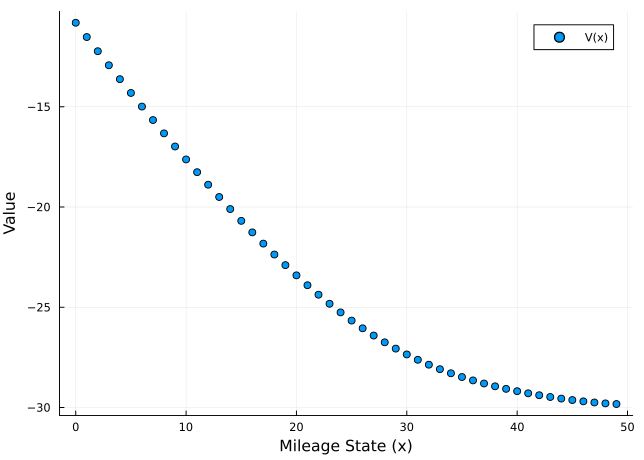

In [1]:
scatter(x̄, V, label="V(x)", legend=:topright)
xlabel!("Mileage State (x)")
ylabel!("Value")

-   Value is **decreasing** in mileage — higher mileage means higher
    costs ahead

### Choice-Specific Values


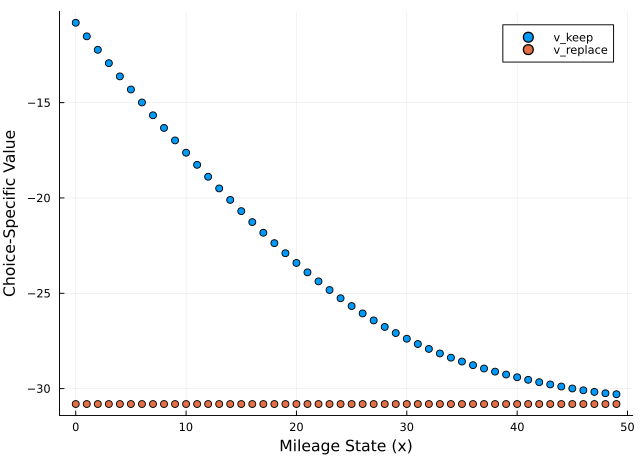

In [1]:
v_keep = -c + β * (F0 * V)                          # value of keeping
v_replace = (-RC) .+ β * (F1 * V)                   # value of replacing
scatter(x̄, v_keep, label="v_keep", legend=:topright)
scatter!(x̄, v_replace, label="v_replace")
xlabel!("Mileage State (x)")
ylabel!("Choice-Specific Value")

-   At low mileage: $v^{\text{keep}} > v^{\text{replace}}$ (keeping is
    better)
-   At high mileage: $v^{\text{replace}} > v^{\text{keep}}$ (replacing
    is better)

### Replacement Probability


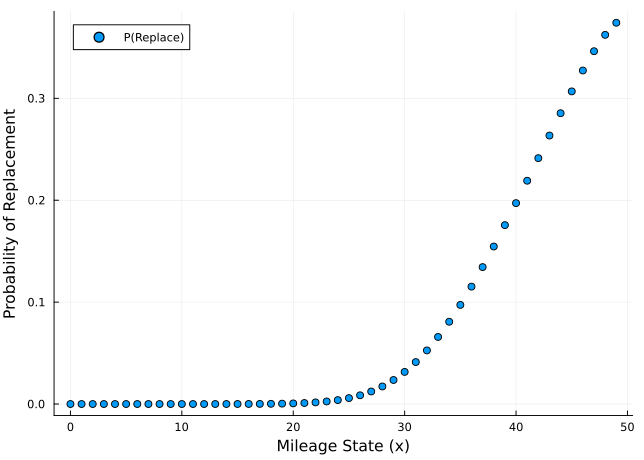

In [1]:
P_rep = 1 ./ (1 .+ exp.(v_keep - v_replace))        # logit formula
scatter(x̄, P_rep, label="P(Replace)", legend=:topleft)
xlabel!("Mileage State (x)")
ylabel!("Probability of Replacement")

-   **S-shaped curve**: smooth transition from “never replace” to
    “always replace”
-   Analogous to the **reservation wage** in McCall, but here it’s a
    **reservation mileage**

### The `solveBellman` Function

-   Wrap the VFI loop in a reusable function:

In [1]:
function solveBellman(m::RustModel, F0, F1; tol=1e-10)
    V = zeros(m.S)                                   # initial guess
    dist = 1.0
    while dist > tol                                 # iterate until convergence
        V_new = iterateBellman(m, V, F0, F1)
        dist = norm(V - V_new, Inf)
        V = V_new
    end
    return V
end

solveBellman (generic function with 1 method)

### The `solveRust` Function

-   Build transitions, solve the Bellman equation, and compute choice
    probabilities:

In [1]:
function solveRust(m::RustModel)
    #build transition matrices
    #solve the Bellman equation
    #compute choice probabilities
    #return tuple with solution
end

solveRust (generic function with 1 method)

### The `solveRust` Function

-   Build transitions, solve the Bellman equation, and compute choice
    probabilities:

In [1]:
function solveRust(m::RustModel)
    (; β, RC, c, θ₃, S) = m
    #build transition matrices
    F0, F1 = buildTransition(θ₃, S)
    #solve the Bellman equation
    V = solveBellman(m, F0, F1)                      # solve the DP
    #compute choice probabilities
    v_keep = -c + β * (F0 * V)                       # choice-specific values
    v_replace = (-RC) .+ β * (F1 * V)
    P_rep = 1 ./ (1 .+ exp.(v_keep - v_replace))     # logit choice probabilities
    #return tuple with solution
    return (V=V, P=P_rep, v_keep=v_keep, v_replace=v_replace)
end

solveRust (generic function with 1 method)

### Using `solveRust`

In [1]:
sol = solveRust(m)
sol.P[1:5]                 # replacement probability at low mileage

5-element Vector{Float64}:
 2.0611536181902037e-9
 4.202144358547094e-9
 8.518414382484044e-9
 1.716378823590513e-8
 3.436078646097847e-8

In [1]:
sol = solveRust(m)
sol.P[45:50]                 # replacement probability at high mileage

6-element Vector{Float64}:
 0.28538319126651995
 0.30679678501323937
 0.327286517407775
 0.3462258786024322
 0.36228389282489815
 0.37415329641332795

## Comparative Statics

### Effect of Replacement Cost ($RC$)


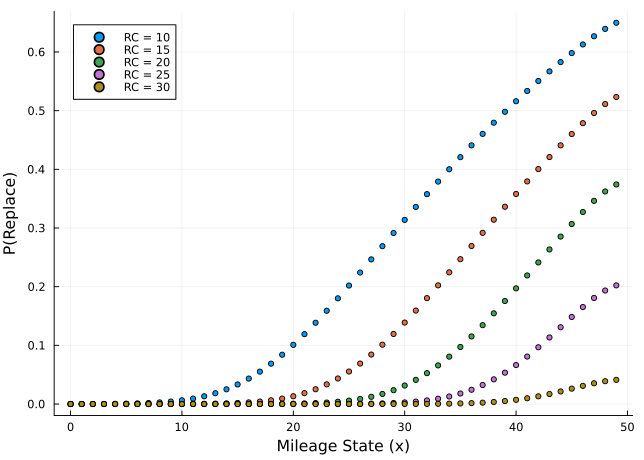

In [1]:
plot()
for RC_val in [10.0, 15.0, 20.0, 25.0, 30.0]
    sol = solveRust(RustModel(RC=RC_val))
    scatter!(x̄, sol.P, label="RC = $(Int(RC_val))", markersize=3)
end
xlabel!("Mileage State (x)")
ylabel!("P(Replace)")

. . .

-   Higher $RC$ $\rightarrow$ agent waits **longer** before replacing
    $\rightarrow$ threshold shifts right

### Effect of Maintenance Cost ($\theta_1$)


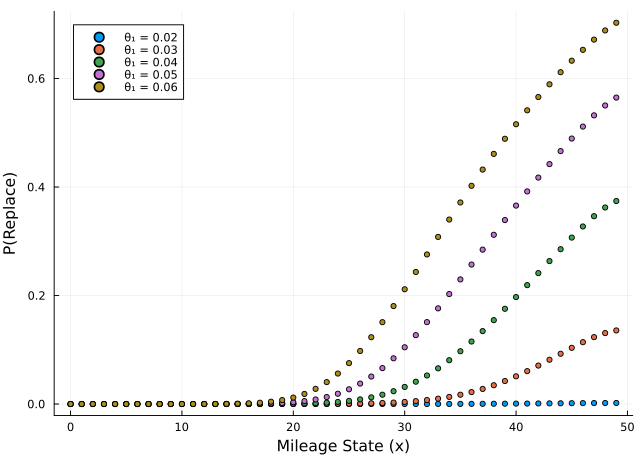

In [1]:
plot()
for θ₁_val in [0.02, 0.03, 0.04, 0.05, 0.06]
    sol = solveRust(RustModel(θ₁=θ₁_val))
    scatter!(x̄, sol.P, label="θ₁ = $θ₁_val", markersize=3)
end
xlabel!("Mileage State (x)")
ylabel!("P(Replace)")

. . .

-   Higher $\theta_1$ $\rightarrow$ maintenance costs rise **faster**
    $\rightarrow$ agent replaces **sooner**

### Comparing to McCall

| Comparative Static | McCall | Rust |
|------------------------|------------------------|------------------------|
| **Higher benefits / lower RC** | More selective (higher reservation wage) | Less replacement (higher threshold mileage) |
| **Higher firing rate / higher $\theta_1$** | Less selective (lower reservation wage) | More replacement (lower threshold mileage) |
| **Higher $\beta$** | More selective (patient, wait for good offers) | More replacement (forward-looking, avoid future costs) |

# Estimation

## What We Observe

### The Econometrician’s Problem

-   We observe a **panel** of buses over time:
    -   Mileage state $x_t$ at each period
    -   Replacement decision $d_t \in \{0, 1\}$

. . .

-   We do **not** observe:
    -   The cost parameters $\theta_1$ and $RC$
    -   The unobserved shocks $\varepsilon_t$

. . .

> **Goal**
>
> Recover the **structural parameters** $(\theta_1, RC, \theta_3)$ from
> the observed data $(x_t, d_t)$.

### The Log-Likelihood Function

-   The probability of the observed data given parameters:

$$
\ell(\theta) = \sum_{t=1}^{T} \left[ d_t \log P(d_t=1 \mid x_t, \theta) + (1-d_t) \log P(d_t=0 \mid x_t, \theta) \right]
$$

. . .

-   $P(d=1 \mid x, \theta)$ comes from the **logit formula** — but
    requires solving the **entire DP** to compute!

### Two-Step Estimation

> **Key Insight**
>
> The transition probabilities $\theta_3$ can be estimated
> **separately** from $(RC, \theta_1)$:
>
> 1.  **Step 1**: Estimate $\hat\theta_3$ directly from mileage
>     transitions (just counting)
> 2.  **Step 2**: Given $\hat\theta_3$, estimate $(RC, \theta_1)$ by
>     maximizing the choice likelihood using **NFXP**

. . .

-   This works because $\theta_3$ only affects the **transition** part
    of the likelihood, while $(RC, \theta_1)$ only affect the **choice**
    part (through the DP solution)

## Simulating Data

### The Simulation Function

In [1]:
function simulateRust(P_rep, θ₃, S, T; seed=42)
    Random.seed!(seed)
    x_sim = zeros(Int, T)                            # mileage states
    d_sim = zeros(Int, T)                            # replacement decisions
    x_sim[1] = 1                                     # start at state 1 (0 mileage)

    for t in 1:T
        d_sim[t] = rand() < P_rep[x_sim[t]] ? 1 : 0 # Bernoulli draw

        if t < T
            Δ = rand(Categorical(θ₃)) - 1            # mileage increment: 0, 1, or 2
            if d_sim[t] == 1
                x_sim[t+1] = min(1 + Δ, S)           # replace: reset then increment
            else
                x_sim[t+1] = min(x_sim[t] + Δ, S)    # keep: current + increment
            end
        end
    end
    return x_sim, d_sim
end

simulateRust (generic function with 1 method)

### Generating Simulated Data

In [1]:
m = RustModel()                                      # true model
sol = solveRust(m)                                    # solve the DP
T = 5000                                             # number of periods

x_sim, d_sim = simulateRust(sol.P, m.θ₃, m.S, T)    # simulate data
println("Replacement rate: ", round(mean(d_sim), digits=3))

Replacement rate: 0.022

### Simulated Mileage Path


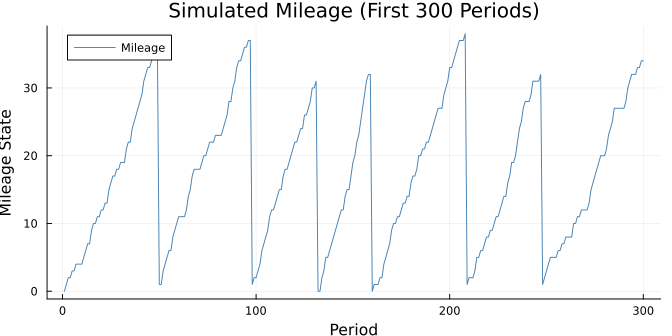

In [1]:
plot(x̄[x_sim[1:300]], linewidth=1, color=:steelblue, label="Mileage",
     title="Simulated Mileage (First 300 Periods)", size=(700, 350))
xlabel!("Period")
ylabel!("Mileage State")

-   **Sawtooth pattern**: mileage gradually rises, then drops sharply at
    replacement

### Mileage Distribution


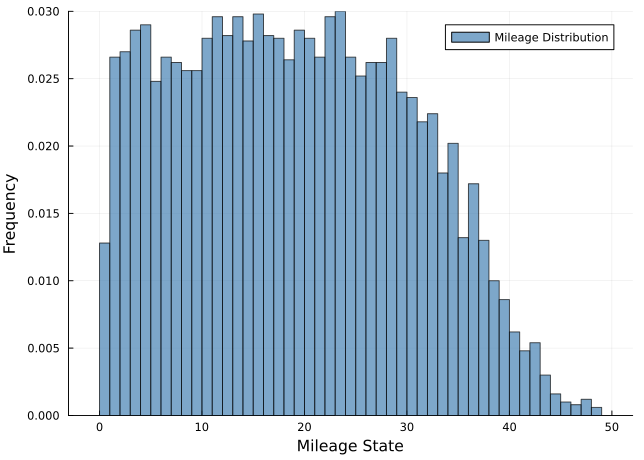

In [1]:
histogram(x̄[x_sim], bins=S, normalize=true, label="Mileage Distribution",
          color=:steelblue, alpha=0.7)
xlabel!("Mileage State")
ylabel!("Frequency")

-   More mass at **low mileage** — buses spend relatively little time at
    high mileage before being replaced

## The NFXP Algorithm

### Step 1: Estimate Transition Probabilities

-   Count mileage increments from the data:

In [1]:
counts = zeros(3)                                    # for Δ = 0, 1, 2
for t in 1:T-1
    if d_sim[t] == 0 && x_sim[t] <= S - 2           # keep, away from boundary
        Δ = x_sim[t+1] - x_sim[t]
        counts[Δ + 1] += 1
    elseif d_sim[t] == 1                             # replace
        Δ = x_sim[t+1] - 1                           # next state = 1 + Δ
        counts[Δ + 1] += 1
    end
end

θ₃_hat = counts / sum(counts)                       # estimated transition probs
println("True θ₃:      ", round.(m.θ₃, digits=3))
println("Estimated θ₃: ", round.(θ₃_hat, digits=3))

True θ₃:      [0.36, 0.48, 0.16]
Estimated θ₃: [0.351, 0.486, 0.163]

### Step 2: The NFXP Concept

For each candidate $\theta = (RC, \theta_1)$:

1.  **Inner loop**: Solve the DP via VFI $\rightarrow$ get $EV_\theta$
2.  Compute choice probabilities $P(d \mid x, \theta)$
3.  Evaluate the log-likelihood:

$$
\ell(\theta) = \sum_{t=1}^{T} \left[ d_t \log P(d_t=1 \mid x_t, \theta) + (1-d_t) \log P(d_t=0 \mid x_t, \theta) \right]
$$

. . .

**Outer loop**: Search over $\theta$ to maximize $\ell(\theta)$

. . .

> **Why “Nested”?**
>
> Every single evaluation of the likelihood requires **solving the
> entire dynamic program**. The fixed point (VFI) is nested inside the
> optimization.

### Step 2: The NFXP Concept

For each candidate $\theta = (RC, \theta_1)$:

1.  **Inner loop**: Solve the DP via VFI $\rightarrow$ get $EV_\theta$
2.  Compute choice probabilities $P(d \mid x, \theta)$
3.  Evaluate the log-likelihood:

$$
\ell(\theta) = \sum_{t=1}^{T} \left[ {\color{red}\underbrace{d_t \log P(d_t=1 \mid x_t, \theta)}_{\text{Replacement likelihood}}} + {\color{blue}\underbrace{(1-d_t) \log P(d_t=0 \mid x_t, \theta)}_{\text{Keep likelihood}}} \right]
$$

**Outer loop**: Search over $\theta$ to maximize $\ell(\theta)$

> **Why “Nested”?**
>
> Every single evaluation of the likelihood requires **solving the
> entire dynamic program**. The fixed point (VFI) is nested inside the
> optimization.

### The NFXP Objective Function

In [1]:
function nfxpObjective(params, x_data, d_data, β, θ₃_hat, S)
    # unpack candidate parameters (RC, θ₁)
    # check parameter bounds
    # build trial model and solve the DP (inner loop)
    # compute log-likelihood from choice probabilities
    # return negative log-likelihood (for minimization)
end

nfxpObjective (generic function with 1 method)

### The NFXP Objective Function

In [1]:
function nfxpObjective(params, x_data, d_data, β, θ₃_hat, S)
    # unpack candidate parameters (RC, θ₁)
    RC_est, θ₁_est = params
    # check parameter bounds
    if RC_est < 0 || θ₁_est < 0
        return 1e10
    end
    # build trial model and solve the DP (inner loop)
    m_trial = RustModel(β=β, S=S, RC=RC_est, θ₁=θ₁_est, θ₃=θ₃_hat)
    sol = solveRust(m_trial)
    # compute log-likelihood from choice probabilities
    ll = 0.0
    for t in eachindex(d_data)
        s = x_data[t]
        ll += d_data[t] * log(max(sol.P[s], 1e-15)) +
              (1 - d_data[t]) * log(max(1 - sol.P[s], 1e-15))
    end
    # return negative log-likelihood (for minimization)
    return -ll
end

nfxpObjective (generic function with 1 method)

### Running the Estimation

In [1]:
using Optim

In [1]:
result = optimize(
    p -> nfxpObjective(p, x_sim, d_sim, β, θ₃_hat, S),
    [15.0, 0.03],                                    # initial guess: [RC, θ₁]
    NelderMead(),                                    # derivative-free optimizer
    Optim.Options(iterations=5000)
)
RC_hat, θ₁_hat = Optim.minimizer(result)

2-element Vector{Float64}:
 21.220120311603008
  0.04306776468765347

### Comparing Estimates to Truth

In [1]:
println("────────────────────────────────────────")
println("Parameter │   True   │ Estimated")
println("────────────────────────────────────────")
println("    RC    │  $(lpad(m.RC, 6))  │  $(lpad(round(RC_hat, digits=3), 6))")
println("    θ₁    │  $(lpad(m.θ₁, 6))  │  $(lpad(round(θ₁_hat, digits=4), 6))")
println("────────────────────────────────────────")

────────────────────────────────────────
Parameter │   True   │ Estimated
────────────────────────────────────────
    RC    │    20.0  │   21.22
    θ₁    │    0.04  │  0.0431
────────────────────────────────────────

### Estimated vs. True Replacement Probability


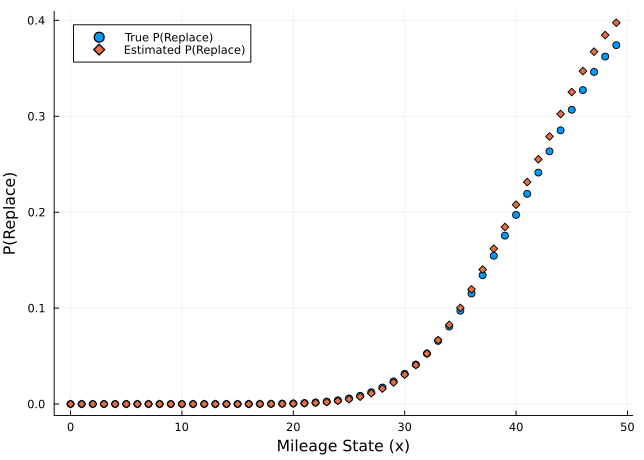

In [1]:
m_hat = RustModel(RC=RC_hat, θ₁=θ₁_hat, θ₃=θ₃_hat)  # estimated model
sol_hat = solveRust(m_hat)

scatter(x̄, sol.P, label="True P(Replace)", markersize=4)
scatter!(x̄, sol_hat.P, label="Estimated P(Replace)", markersize=4,
         markershape=:diamond)
xlabel!("Mileage State (x)")
ylabel!("P(Replace)")

-   The estimated choice probabilities should closely match the true
    ones

### Why Structural Estimation?

> **The Power of Structural Models**
>
> With the estimated structural parameters, we can perform
> **counterfactual analysis**:
>
> -   What if the government **subsidizes replacement** (lowers $RC$)?
> -   What if a new technology **reduces maintenance costs** (lowers
>     $\theta_1$)?
> -   What if buses are driven **more intensively** (changes
>     $\theta_3$)?
>
> A reduced-form model (e.g., a logit on current mileage) **cannot**
> answer these questions — it would break under the policy change. The
> structural model accounts for how agents **re-optimize** under new
> conditions.

# Summary

### Key Takeaways

**Concepts**

-   Dynamic discrete choice models
-   Bellman equation with logit shocks
-   Value function iteration
-   Reservation mileage (analog of reservation wage)
-   NFXP: structural estimation of DPs
-   Counterfactual policy analysis

**Julia Tools**

-   `max.()`, `exp.()`, `log.()` broadcasting
-   `norm()` for convergence checks
-   Matrix multiplication for transitions
-   Structs with `@kwdef`, destructuring `(; ...)`
-   `Categorical` for discrete simulation
-   `Optim.jl` for maximum likelihood

. . .

> **Remember**
>
> Rust (1987) showed that **dynamic programming models can be estimated
> from data**. The key ingredients: (1) a structural model of
> forward-looking behavior, (2) distributional assumptions on
> unobservables, and (3) the NFXP algorithm to solve the model inside
> the estimator.